[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/rafelsalgueiro/GallegoSalgueiroVera/blob/main/Entornos_Complejos/estudio_tabulares.ipynb)

# Estudio comparativo de métodos tabulares en gymnasium con el problema simplegrid

*Description:* Este notebook realiza un estudio experimental de algoritmos de Reinforcement Learning tabular en un entorno tipo SimpleGrid generado de forma procedural. En cada episodio se crea un mapa distinto, lo que introduce variabilidad estructural en el entorno y aumenta la dificultad del problema.

Se comparan los siguientes algoritmos: 

- SARSA (on-policy TD control)
- Q-Learning (off-policy TD control)
- Monte Carlo On-Policy
- Monte Carlo Off-Policy

Se analizan métricas como:

- Tasa de éxito
- Recompensa total por episodio
- Número de pasos hasta alcanzar la meta
- Evolución temporal del rendimiento

El objetivo es evaluar la capacidad de los distintos métodos para aprender una política eficaz en un entorno dinámico donde la disposición de obstáculos cambia entre episodios.

 #### El Problema: Control en SimpleGrid con mapas variables
El problema consiste en un agente que debe navegar desde una posición inicial hasta una meta dentro de un entorno tipo SimpleGrid, evitando obstáculos.
A diferencia del caso clásico con mapa fijo, en este estudio:

- En cada episodio se genera un nuevo mapa proceduralmente.
- La distribución de obstáculos cambia.
- El agente debe aprender una política robusta que funcione bien en promedio sobre múltiples configuraciones del entorno.
- El estado representa la posición del agente en la cuadrícula y las acciones disponibles corresponden a los movimientos cardinales (arriba, abajo, izquierda, derecha).

El objetivo es maximizar la recompensa acumulada, lo que equivale a:

- Alcanzar la meta en el menor número posible de pasos.
- Minimizar penalizaciones por movimientos innecesarios.

Este planteamiento introduce un componente de generalización, ya que el agente no memoriza un único mapa, sino que aprende un comportamiento que debe adaptarse a distintas configuraciones estructurales del entorno.

```
Authors: Gallego, Salgueiro y Vera.
Date: 2026/02/16
```

## 1. Preparación del entorno
A continuación están todos los requisitos Python para este estudio, importándose las librerías necesarias.

In [1]:
!git clone https://github.com/rafelsalgueiro/GallegoSalgueiroVera.git

Cloning into 'GallegoSalgueiroVera'...


In [2]:
!pip install matplotlib numpy seaborn gymnasium gym-simplegrid tqdm

In [3]:
!cd GallegoSalgueiroVera/Entornos_Complejos && pwd

"pwd" no se reconoce como un comando interno o externo,
programa o archivo por lotes ejecutable.


In [4]:
import os
import sys
import random
import numpy as np
import gymnasium as gym
import gym_simplegrid
from tqdm import tqdm
from collections import deque

project_root = os.path.abspath('GallegoSalgueiroVera/Entornos_Complejos')
if project_root not in sys.path:
    sys.path.insert(0, project_root)

try:
    from src.agents import *
    from src.plotting import *
    print("Entorno cargado correctamente.")

except ImportError as e:
    print(f"Error cargando el entorno: {e}")
    sys.exit(1)
    
# Parámetros del experimento
seed = 42
random.seed(seed) # Fijar la semilla para reproducibilidad
np.random.seed(seed)
np.random.default_rng(seed)
os.environ['PYTHONHASHSEED'] = str(seed)  

Entorno cargado correctamente.


## 2. Definición del entorno y aleatorización

Este bloque gestiona la creación dinámica y estructurada de los laberintos que conformarán el entorno de aprendizaje. Mediante generación procedimental, construye cuadrículas aleatorias basándose en una probabilidad de obstáculos predefinida, asegurando siempre que la salida y la meta estén despejadas.

Para garantizar que el entrenamiento no se estanque ni penalice injustamente al agente en escenarios imposibles, el código implementa un algoritmo de Búsqueda en Anchura (BFS). Este mecanismo verifica matemáticamente que exista al menos una ruta continua desde el inicio hasta el objetivo; si un mapa generado resulta estar completamente bloqueado, el bucle lo descarta automáticamente y genera uno nuevo hasta asegurar un entorno 100% resoluble.

In [5]:
def es_mapa_valido(mapa, size):
    """Comprueba por BFS si el laberinto tiene solución."""
    inicio, meta = (0, 0), (size - 1, size - 1)
    cola = deque([inicio])
    visitados = set([inicio])
    direcciones = [(-1, 0), (1, 0), (0, -1), (0, 1)]
    
    while cola:
        fila, col = cola.popleft()
        if (fila, col) == meta:
            return True
            
        for df, dc in direcciones:
            n_fila, n_col = fila + df, col + dc
            if 0 <= n_fila < size and 0 <= n_col < size:
                if (n_fila, n_col) not in visitados and mapa[n_fila][n_col] == '0':
                    visitados.add((n_fila, n_col))
                    cola.append((n_fila, n_col))
    return False

def generar_mapa_procedural_valido(size=4, prob_muro=0.25):
    """Genera mapas en bucle hasta devolver una matriz 100% resolvible."""
    while True:
        mapa = []
        for fila in range(size):
            fila_str = ""
            for col in range(size):
                if (fila == 0 and col == 0) or (fila == size-1 and col == size-1):
                    fila_str += "0"
                else:
                    fila_str += "1" if random.random() < prob_muro else "0"
            mapa.append(fila_str)
            
        if es_mapa_valido(mapa, size):
            return mapa

## 3. Entrenamientos

Este bloque define las rutinas de entrenamiento principales, estructuradas según el método de actualización de cada familia de algoritmos. La función entrenar_agente_td (para SARSA y Q-Learning) implementa un aprendizaje basado en Diferencias Temporales, actualizando el conocimiento del agente paso a paso a medida que interactúa con el entorno. En contraste, entrenar_agente_mc acumula las transiciones de toda la trayectoria y retrasa la actualización hasta el final del episodio, como es propio de los métodos de Monte Carlo. Para asegurar que los agentes generalicen y no memoricen una única ruta, ambas funciones generan un laberinto procedimental nuevo en cada iteración, limitan la exploración a 100 pasos para evitar bucles infinitos y devuelven el registro de métricas de rendimiento, incluyendo un bloque para gestionar de forma segura el cierre del entorno.

In [6]:
def entrenar_agente_td(agent, env_name="SimpleGrid-v0", episodios=1000):
    """Bucle de entrenamiento para SARSA y Q-Learning."""
    longitudes, recompensas, exitos = [], [], []
    
    for ep in tqdm(range(episodios), desc=f"Entrenando {type(agent).__name__}"):
        mapa_nuevo = generar_mapa_procedural_valido(size=4, prob_muro=0.25)
        env = gym.make(env_name, obstacle_map=mapa_nuevo)
        
        state, _ = env.reset(seed=seed+ep, options={'start_loc': 0, 'goal_loc': 15})
        done = False
        pasos, recompensa_ep = 0, 0
        action = agent.get_action(state)
        
        while not done:
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            next_action = agent.get_action(next_state)
            
            if isinstance(agent, SarsaAgent):
                agent.update(state, action, reward, next_state, next_action, done)
            else:
                agent.update(state, action, reward, next_state, done)
                
            state, action = next_state, next_action
            pasos += 1
            recompensa_ep += reward
            
            if pasos > 100: 
                break
                
        longitudes.append(pasos)
        recompensas.append(recompensa_ep)
        exitos.append(1 if reward > 0 else 0)
        try:        #Solucion a bug de la libreria, con env.close() se cierra el entorno y hace un sys.exit()
            env.close()
        except SystemExit:
            pass
        
    return longitudes, recompensas, exitos


def entrenar_agente_mc(agent, env_name="SimpleGrid-v0", episodios=1000):
    """Bucle de entrenamiento para Monte Carlo."""
    longitudes, recompensas, exitos = [], [], []
    
    for ep in tqdm(range(episodios), desc=f"Entrenando {type(agent).__name__}"):
        mapa_nuevo = generar_mapa_procedural_valido(size=4, prob_muro=0.25)
        env = gym.make(env_name, obstacle_map=mapa_nuevo)
        
        state, _ = env.reset(seed=seed+ep, options={'start_loc': 0, 'goal_loc': 15})
        done = False
        pasos, recompensa_ep = 0, 0
        
        while not done:
            action = agent.get_action(state)
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            
            agent.store_transition(state, action, reward)
            
            state = next_state
            pasos += 1
            recompensa_ep += reward
            
            if pasos > 100:
                break
                
        agent.update()
        longitudes.append(pasos)
        recompensas.append(recompensa_ep)
        exitos.append(1 if reward > 0 else 0)
        try:        #Solucion a bug de la libreria, con env.close() se cierra el entorno y hace un sys.exit()
            env.close()
        except SystemExit:
            pass
        
    return longitudes, recompensas, exitos

## 4. Ejecución de Experimentos

Este bloque de código configura y ejecuta el experimento principal, entrenando a los cuatro agentes durante 1500 episodios. Primero, genera dinámicamente un mapa de cuadrícula de 4x4 con un 25% de probabilidad de obstáculos, estableciendo así el entorno de simulación base para la prueba.

Luego, inicializa a SARSA, Q-Learning y las dos variantes de Monte Carlo con los mismos hiperparámetros base (como epsilon=0.1 y gamma=0.99) para asegurar una comparativa totalmente justa. Finalmente, lanza las rutinas de entrenamiento correspondientes a cada familia de algoritmos, recopilando y guardando en variables las métricas de pasos, recompensas y éxito que alimentarán las gráficas posteriores.

In [7]:
num_episodios = 1500

mapa_dummy = generar_mapa_procedural_valido(size=4, prob_muro=0.25)
env_dummy = gym.make('SimpleGrid-v0', obstacle_map=mapa_dummy)

sarsa = SarsaAgent(env_dummy, alpha=0.1, gamma=0.99, epsilon=0.1)
q_learning = QLearningAgent(env_dummy, alpha=0.1, gamma=0.99, epsilon=0.1)
mc_on = MCOnPolicyAgent(env_dummy, gamma=0.99, epsilon=0.1)
mc_off = MCOffPolicyAgent(env_dummy, gamma=0.99, epsilon=0.1)

len_sarsa, rew_sarsa, succ_sarsa = entrenar_agente_td(sarsa, episodios=num_episodios)
len_ql, rew_ql, succ_ql = entrenar_agente_td(q_learning, episodios=num_episodios)
len_mc, rew_mc, succ_mc = entrenar_agente_mc(mc_on, episodios=num_episodios)
len_mc_off, rew_mc_off, succ_mc_off = entrenar_agente_mc(mc_off, episodios=num_episodios)

Entrenando SarsaAgent:   0%|          | 0/1500 [00:00<?, ?it/s]

Entrenando MCOffPolicyAgent: 100%|██████████| 1500/1500 [00:01<00:00, 1188.55it/s]


## Visualización de Resultados

Este bloque de código automatiza la visualización de resultados para evaluar y comparar el rendimiento de tus cuatro agentes de aprendizaje por refuerzo de forma clara y estandarizada. Comienza utilizando una función que genera etiquetas dinámicas automáticamente, extrayendo el nombre de cada algoritmo y sus hiperparámetros clave (como la tasa de aprendizaje y el factor de descuento) para que las leyendas de los gráficos se documenten solas.

A continuación, el script realiza un análisis individual de cada agente trazando sus curvas de longitud de episodio y recompensa acumulada. Para que las tendencias subyacentes de aprendizaje sean legibles y no queden ocultas por el ruido natural de la exploración del agente, aplica un suavizado matemático utilizando una media móvil de los últimos 50 episodios.

Finalmente, el código agrupa las métricas para generar gráficas comparativas globales. Al colocar el rendimiento de los cuatro algoritmos sobre los mismos ejes, te permite identificar de un vistazo cuál converge más rápido hacia la meta y cuál maximiza mejor su puntuación. El proceso concluye graficando la tasa de éxito individual, mostrándote la evolución de la confiabilidad de cada modelo a lo largo del entrenamiento.

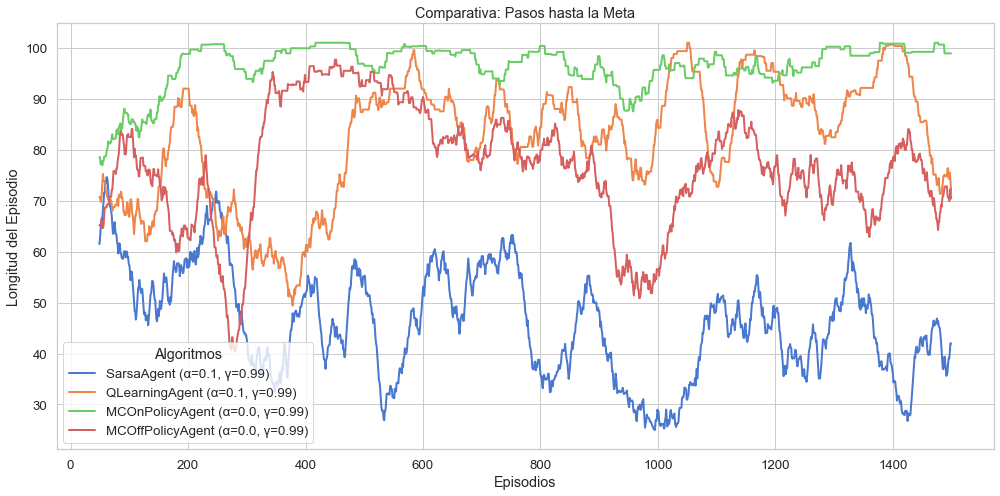

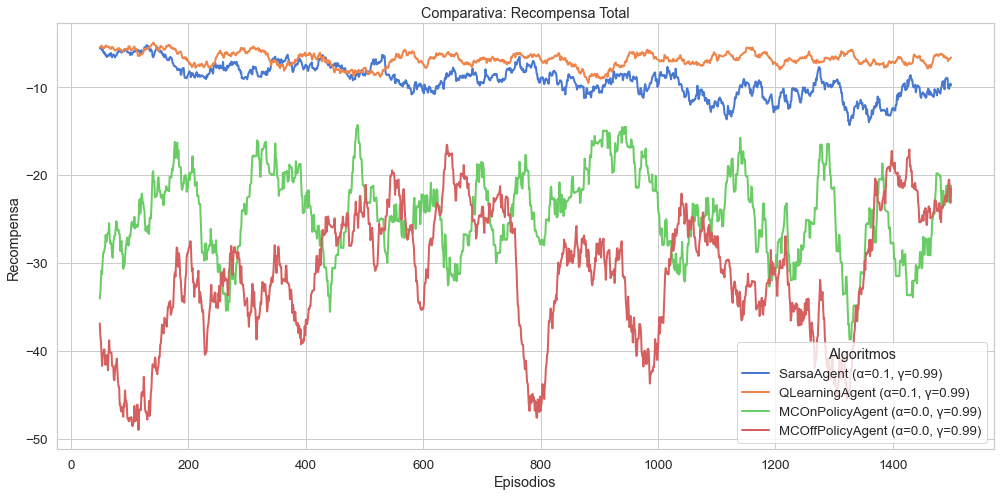

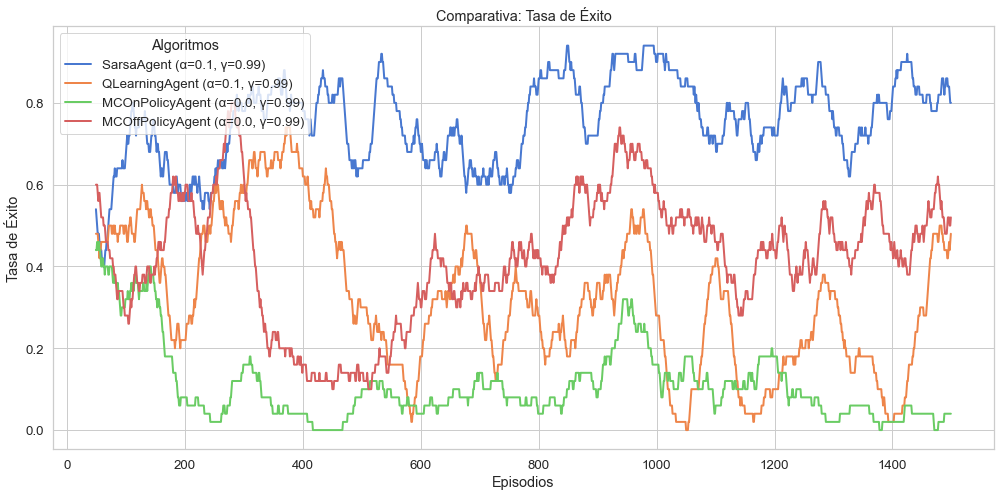

In [8]:
def get_agent_label(agent):
    """Genera una etiqueta descriptiva para el algoritmo."""
    label = type(agent).__name__
    if hasattr(agent, 'alpha') and hasattr(agent, 'gamma'):
        label += f" (α={agent.alpha}, γ={agent.gamma})"
    elif hasattr(agent, 'gamma'):
         label += f" (γ={agent.gamma})"
    return label

# Definimos la lista de agentes y sus datos correspondientes
agentes_list = [sarsa, q_learning, mc_on, mc_off]
data_lengths = [len_sarsa, len_ql, len_mc, len_mc_off]
data_rewards = [rew_sarsa, rew_ql, rew_mc, rew_mc_off]
data_success = [succ_sarsa, succ_ql, succ_mc, succ_mc_off]

# Diccionario para comparar longitudes (pasos hasta la meta)
dict_longitudes = {get_agent_label(a): d for a, d in zip(agentes_list, data_lengths)}
plot_comparative_curves(dict_longitudes, window_size=50, title="Comparativa: Pasos hasta la Meta", ylabel="Longitud del Episodio")

# Diccionario para comparar recompensas totales
dict_recompensas = {get_agent_label(a): d for a, d in zip(agentes_list, data_rewards)}
plot_comparative_curves(dict_recompensas, window_size=50, title="Comparativa: Recompensa Total", ylabel="Recompensa")

# Diccionario para comparar tasas de éxito
dict_success = {get_agent_label(a): d for a, d in zip(agentes_list, data_success)}
plot_comparative_curves(dict_success, window_size=50, title="Comparativa: Tasa de Éxito", ylabel="Tasa de Éxito")

# 5. Conclusiones

En términos generales, el análisis de las métricas revela que la familia de algoritmos basados en Diferencias Temporales (TD) es ampliamente superior a los métodos de Monte Carlo para este entorno particular, destacando SARSA como la solución más robusta y fiable.

El rendimiento de SARSA demuestra la gran ventaja de su enfoque on-policy en escenarios donde la penalización por errores es alta. Al observar su gráfica de longitud de episodio, se aprecia una evolución estable: tras una fase inicial de exploración, el agente logra mantener la duración de sus trayectorias en una franja contenida (principalmente entre 30 y 60 pasos). Su curva de recompensa acumulada es consistentemente la menos ruidosa entre los métodos evaluados. Esta capacidad para tener en cuenta sus propios movimientos exploratorios a la hora de actualizar la política le permite aprender rutas seguras, lo que se traduce en una tasa de éxito alta y sostenida en el tiempo.

En marcado contraste, Q-Learning exhibe un comportamiento caracterizado por una volatilidad extrema. Su gráfica individual de longitud de episodio ilustra este fenómeno a la perfección: aunque es capaz de encontrar rutas óptimas muy rápidas de forma puntual (llegando a caer a la franja de los 20-30 pasos cerca del episodio 650), es incapaz de mantener este rendimiento, rebotando repetidamente hacia el límite máximo de 100 pasos. Esta inestabilidad sistemática es inherente a su naturaleza off-policy; al actualizar sus estimaciones asumiendo que siempre tomará la mejor acción futura, el agente ignora los riesgos reales de su propia tasa de exploración ($\epsilon$). El resultado es una política "temeraria" que colapsa fácilmente, reflejándose en caídas drásticas tanto en su recompensa como en su tasa de éxito.

Por su parte, los métodos de Monte Carlo (MC) demuestran ser inadecuados para la dinámica de este problema. La variante MC On-Policy sufre un estancamiento prematuro y total, siendo incapaz de descifrar el entorno (manteniéndose atascada en el límite de pasos con una tasa de éxito nula). Aunque MC Off-Policy logra un aprendizaje parcial y oscilante, su elevada varianza y su incapacidad para estabilizar las recompensas o la duración de los episodios evidencian que esperar al final de la trayectoria para propagar los valores no proporciona una señal de aprendizaje lo suficientemente ágil.

En definitiva, para este entorno, la actualización incremental (paso a paso) es fundamental, y la adopción de una política conservadora (SARSA) resulta una elección mucho más efectiva a largo plazo que la búsqueda agresiva pero inestable de la ruta óptima teórica (Q-Learning).